## Regional SAT anomalies calculation then calculate the trend

In [1]:
# In[1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# %%
# define function
import src.SAT_function_Obs_Fingerprint as data_process
import src.Data_Preprocess as preprocess

In [2]:
# import src.slurm_cluster as scluster
# client, scluster = scluster.init_dask_slurm_cluster(scale=2,cores=10, memory="200GB")

In [3]:
def func_mk(x):
    """
    Mann-Kendall test for trend
    """
    results = data_process.mk_test(x)
    slope = results[0]
    p_val = results[1]
    return slope, p_val

In [4]:
# load data
dir_HadCRUT5 = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG2/'
HadCRUT5 = xr.open_dataset(dir_HadCRUT5 + 'Raw_HadCRUT5_MK_trend_1950-2022_sliding.nc')

# dir_forced_unforced_anom = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIGS5_S6/cesm2_100/'
# HadCRUT5_partition_anom = xr.open_mfdataset(dir_forced_unforced_anom + 'OBS_SAT_anomaly_partition_wrt_MMLE_ENS.nc',chunks={'lat':10,'lon':10})
dir_forced_unforced = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIGS5_S6/cesm2_100'
HadCRUT5_forced = xr.open_mfdataset(dir_forced_unforced + '/trend_forced_HadCRUT5_annual/' + 'forced_HadCRUT5_MMLE_MK_trend_1950-2022_sliding.nc',chunks={'lat':10,'lon':10}) 
HadCRUT5_internal = xr.open_mfdataset(dir_forced_unforced + '/trend_ICV_HadCRUT5_annual/' + 'ICV_HadCRUT5_MMLE_MK_trend_1950-2022_sliding.nc',chunks={'lat':10,'lon':10})

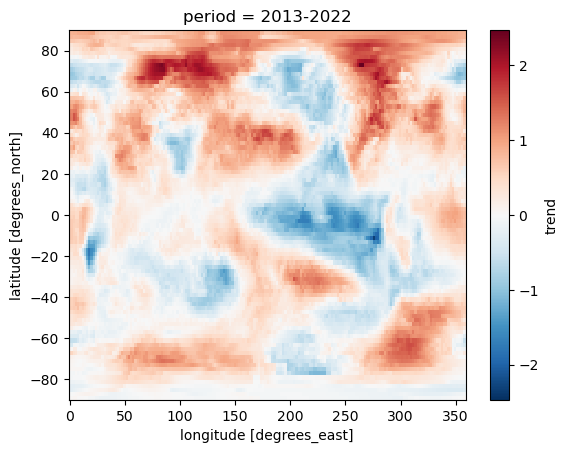

In [5]:
HadCRUT5['trend'].sel(period='2013-2022').plot()

In [6]:
HadCRUT5_forced, HadCRUT5_internal 

(<xarray.Dataset>
 Dimensions:  (lat: 90, lon: 180, period: 64)
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
   * period   (period) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'
 Data variables:
     trend    (period, lat, lon) float64 dask.array<chunksize=(64, 10, 10), meta=np.ndarray>
     p_value  (period, lat, lon) float64 dask.array<chunksize=(64, 10, 10), meta=np.ndarray>,
 <xarray.Dataset>
 Dimensions:  (lat: 90, lon: 180, period: 64)
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
   * period   (period) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'
 Data variables:
     trend    (period, lat, lon) float64 dask.array<chunksize=(64, 10, 10), meta=np.ndarray>
     p_value  (period, lat, lon) float

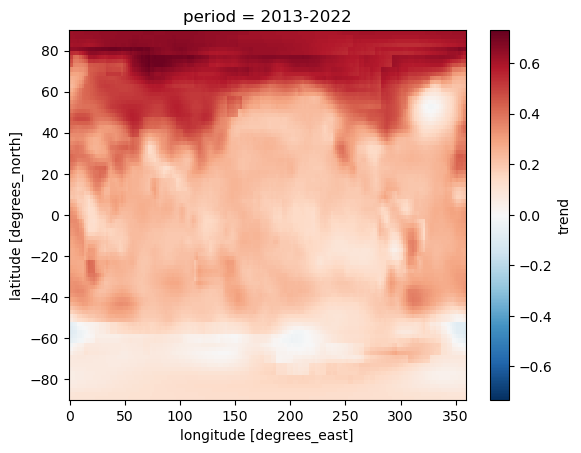

In [7]:
HadCRUT5_forced['trend'].sel(period='2013-2022').plot()

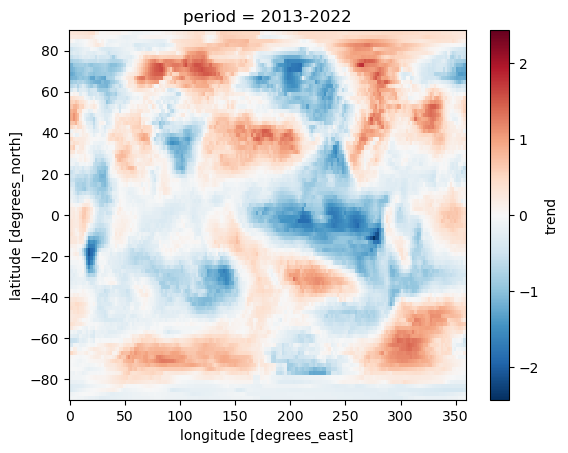

In [8]:
HadCRUT5_internal['trend'].sel(period='2013-2022').plot()

### Calculate the trend end year fix to 2022, start with 73 year length and decrease length of trend every one year, the minimum trend length is 10yr 

In [9]:
temp_data = HadCRUT5.trend
temp_data_forced = HadCRUT5_forced.trend
temp_data_internal = HadCRUT5_internal.trend

### Regional anomalies calculation

In [10]:
def plot_trend(temp_data, lats, lons, levels=None, extend=None, cmap=None, 
                                 title="", ax=None, show_xticks=False, show_yticks=False):
    """
    Plot the trend spatial pattern using Robinson projection with significance overlaid.

    Parameters:
    - temp_data: 2D numpy array with the trend values.
    - lats, lons: 1D arrays of latitudes and longitudes.
    - p_values: 2D array with p-values for each grid point.
    - GMST_p_values: 2D array with GMST p-values for each grid point.
    - title: Title for the plot.
    - ax: Existing axis to plot on. If None, a new axis will be created.
    - show_xticks, show_yticks: Boolean flags to show x and y axis ticks.
    
    Returns:
    - contour_obj: The contour object from the plot.
    """
    # Plotting
    contour_obj = ax.contourf(lons, lats, temp_data, levels=levels, extend=extend, cmap=cmap, transform=ccrs.PlateCarree())

    ax.coastlines(resolution='110m')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      color='gray', alpha=0.35, linestyle='--')

    # Disable labels on the top and right of the plot
    gl.top_labels = False
    gl.right_labels = False

    # Enable labels on the bottom and left of the plot
    gl.bottom_labels = show_xticks
    gl.left_labels = show_yticks
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()
    gl.xlabel_style = {'size': 16}
    gl.ylabel_style = {'size': 16}
    
    if show_xticks:
        gl.bottom_labels = True
    if show_yticks:
        gl.left_labels = True
    
    # ax.set_title(title, loc='center', fontsize=18, pad=5.0)

    return contour_obj
# %%
plt.rcParams['figure.figsize'] = (8, 10)
plt.rcParams['font.size'] = 16
# plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.major.right'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.1
plt.rcParams['savefig.transparent'] = True

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm, ListedColormap
import cartopy.util as cutil
import seaborn as sns
import matplotlib.colors as mcolors
import palettable

In [11]:
lat = temp_data.lat
lon = temp_data.lon

In [12]:
# Extratropical South Pacific region
lat1 = -70
lat2 = -55
lon1 = 180
lon2 = 260

In [13]:
temp_data_SOP,lons_SOP, lats_SOP = data_process.selreg(
        temp_data, lat, lon, lat1=lat1, lat2=lat2, lon1=lon1, 
        lon2=lon2)
temp_forced_da_SOP,lons_SOP, lats_SOP = data_process.selreg(
        temp_data_forced, lat, lon, lat1=lat1, lat2=lat2, lon1=lon1, 
        lon2=lon2)

temp_internal_da_SOP,lons_SOP, lats_SOP = data_process.selreg(
        temp_data_internal, lat, lon, lat1=lat1, lat2=lat2, lon1=lon1, 
        lon2=lon2)  

In [14]:
temp_forced_da_SOP_mean = data_process.calc_weighted_mean(temp_forced_da_SOP)
temp_internal_da_SOP_mean = data_process.calc_weighted_mean(temp_internal_da_SOP)

In [15]:
# calculate the SOP region SAT anomalies
temp_da_SOP_mean = data_process.calc_weighted_mean(temp_data_SOP)

In [16]:
temp_da_SOP_mean

<xarray.DataArray 'trend' (period: 64)>
array([ 0.053852  ,  0.05211517,  0.04742299,  0.05033532,  0.04676757,
        0.04482055,  0.04220567,  0.04089568,  0.03665035,  0.03704143,
        0.03353555,  0.02787173,  0.02590913,  0.01844697,  0.01192049,
        0.00877277,  0.00743931,  0.00180895,  0.00460596,  0.00646518,
        0.00987454,  0.00464698, -0.00525607, -0.01009625, -0.01981988,
       -0.03175762, -0.03965749, -0.04851082, -0.04595892, -0.04955747,
       -0.05271827, -0.03803964, -0.03683099, -0.0415812 , -0.02852582,
       -0.03221162, -0.02368851, -0.02933124, -0.02441148, -0.04088574,
       -0.06291907, -0.0760542 , -0.06634654, -0.05261349, -0.04825824,
       -0.028598  , -0.03450267, -0.070012  , -0.05076077, -0.02221115,
       -0.07942164, -0.13364511, -0.14317673, -0.10119635, -0.06924232,
       -0.03957138,  0.00723588,  0.05388569,  0.08089151,  0.00432785,
       -0.02884703,  0.03698232, -0.11663052, -0.17006115])
Coordinates:
  * period   (period) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'

In [17]:
temp_forced_da_SOP_mean

<xarray.DataArray 'trend' (period: 64)>
dask.array<truediv, shape=(64,), dtype=float64, chunksize=(64,), chunktype=numpy.ndarray>
Coordinates:
  * period   (period) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'

In [18]:
import os

dir_out = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG5/data/'
os.makedirs(dir_out, exist_ok=True)

# temp_da_SOP_mean.to_dataset(name='trend').to_netcdf(dir_out + 'Raw_SOP_trend_1950-2022_sliding.nc')
# temp_forced_da_SOP_mean.to_dataset(name='trend').to_netcdf(dir_out + 'Forced_SOP_trend_1950-2022_sliding.nc')
# temp_internal_da_SOP_mean.to_dataset(name='trend').to_netcdf(dir_out + 'Internal_SOP_trend_1950-2022_sliding.nc')

### Segments definitions

In [19]:
# calculate the trend for each segment
trends = {}
for begin_year in temp_da_SOP_mean.period.values:
    trends[begin_year] = {
        "raw": temp_da_SOP_mean.sel(period=begin_year).values,
        "forced": temp_forced_da_SOP_mean.sel(period=begin_year).values,
        "internal": temp_internal_da_SOP_mean.sel(period=begin_year).values
    }

In [20]:
trends_df = pd.DataFrame.from_dict(trends, orient='index')
trends_df

,raw,forced,internal
1950-2022,0.0538519969167161,0.03430428535546286,0.022155681773603296
1951-2022,0.052115170899665525,0.035294424473625755,0.019496159352336798
1952-2022,0.04742298762050528,0.036237847449301946,0.014120050882616279
1953-2022,0.05033532088294667,0.0372603327724661,0.016381760077004984
1954-2022,0.04676757319172072,0.038272754322844424,0.011967389350890282
...,...,...,...
2009-2022,0.004327849695220429,0.05438916352011314,-0.04985078813438895
2010-2022,-0.02884703421650046,0.0548171414224538,-0.08275869683241091
2011-2022,0.036982321472946895,0.05439799096330335,-0.017178113153730818
2012-2022,-0.11663051894115412,0.05417302048103109,-0.1703524265308752


In [21]:
# data frame to dataset
trends_ds = trends_df.to_xarray()

In [22]:
trends_ds

<xarray.Dataset>
Dimensions:   (index: 64)
Coordinates:
  * index     (index) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'
Data variables:
    raw       (index) object 0.05385 0.05212 0.04742 ... 0.03698 -0.1166 -0.1701
    forced    (index) object 0.0343 0.03529 0.03624 ... 0.0544 0.05417 0.05322
    internal  (index) object 0.02216 0.0195 0.01412 ... -0.01718 -0.1704 -0.223

In [23]:
# export the trend to the netcdf file
import os

dir_out = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG5/data/'
os.makedirs(dir_out, exist_ok=True)
# trends_ds.to_netcdf(dir_out + 'SOP_trend_variations.nc')

In [24]:
dirin = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG5/data/percentile/'
SOP_unforced_lower = xr.open_dataset(f'{dirin}internal_SOP_trend_lower_percentile.nc')
SOP_unforced_upper = xr.open_dataset(f'{dirin}internal_SOP_trend_upper_percentile.nc')

In [25]:
SOP_unforced_lower

<xarray.Dataset>
Dimensions:               (ICV_trend_year_lower: 64)
Coordinates:
  * ICV_trend_year_lower  (ICV_trend_year_lower) object 'ICV_trend_10yr' ... ...
Data variables:
    ICV_trend_lower       (ICV_trend_year_lower) float64 ...

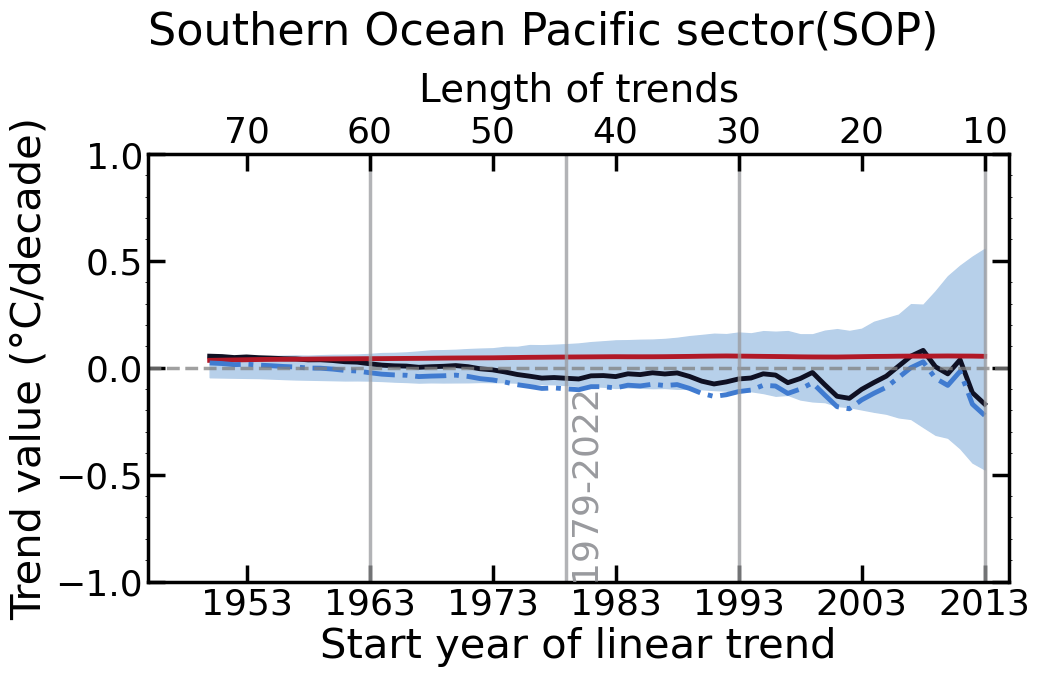

In [28]:
import seaborn as sns
from matplotlib.lines import Line2D

# sns.set_theme(style="whitegrid")
# Set the font dictionaries (for plot title and axis titles)
title_font = {'fontname': 'Arial', 'size': '20', 'color': 'black', 'weight': 'normal',
                'verticalalignment': 'bottom'}  # Bottom vertical alignment for more space
axis_font = {'fontname': 'Arial', 'size': '20'}

# Create the plot
fig = plt.figure(figsize=(25, 15))
gs = gridspec.GridSpec(2, 2, wspace=0.25, hspace=0.7)

ax1 = plt.subplot(gs[0, 0])
# ax2 = plt.subplot(gs[0, 1])
# ax3 = plt.subplot(gs[1, 0])
# ax4 = plt.subplot(gs[1, 1])

# define rgb colors for the outlines
# colors = [(32,120,180), #blue
#           (106,61,154), #purple
#           (173,23,88), #magenta
#           (255,127,0), #orange
#           (226,26,27),#red
#           (49,160,45) #green
#          ]
# colors_set = [(r / 255, g / 255, b / 255) for r, g, b in colors]
colors = ['#0F1023','#B11927', '#407BD0', '#B7D0EA']
line_widths = [5.5, 5.5, 5.5, 5.5, 1.5, 1.5, 1.5]
titles = ['Southern Ocean Pacific sector(SOP)']
linestyles = ['-', '-', '-.', ':']

years = np.arange(1950, 2014)

vars = ['raw', 'forced', 'internal']
# We use a loop to simulate multiple lines for each category
for i, var in enumerate(vars):
    y_vals = trends_ds[var].astype(float).values
    sns.lineplot(x=years, y=y_vals, color=colors[i], linestyle=linestyles[i], linewidth=3.5, ax=ax1)

ax1.fill_between(years, SOP_unforced_lower.ICV_trend_lower.values[::-1], SOP_unforced_upper.ICV_trend_upper.values[::-1], color=colors[3])

ax1.set_xlim([1945, 2015])
ax1.set_ylim([-1.0, 1.0])
ax1.set_xticks([1953, 1963, 1973, 1983, 1993, 2003, 2013])
ax1.set_xticklabels(['1953', '1963', '1973', '1983', '1993', '2003', '2013'])
ax1_upper = ax1.twiny()
ax1_upper.invert_xaxis()
ax1_upper.set_xlim([78,8])
ax1_upper.set_xlabel('Length of trends', fontsize=28, labelpad=10)
ax1_upper.set_xticks([70, 60, 50, 40, 30, 20, 10])
ax1_upper.set_xticklabels(['70', '60', '50', '40', '30', '20', '10'])
ax1.spines['top'].set_linewidth(2.5)
ax1.spines['right'].set_linewidth(2.5)
ax1.spines['bottom'].set_linewidth(2.5)
ax1.spines['left'].set_linewidth(2.5)
ax1_upper.tick_params(axis='x', labelsize=26)
ax1_upper.tick_params(axis='x', which='major', length=12, width=2.5, direction='in')
ax1.axhline(y=0, color='grey', linestyle='--', linewidth=2.5, alpha=0.75)
ax1.set_ylabel('Trend value (°C/decade)', fontsize=30)
ax1.set_xlabel('Start year of linear trend', fontsize=30)
ax1.set_title(titles[0], loc='left',fontsize=32,pad=20)
ax1.tick_params(axis='x', which='major', length=12, labelsize=26, width=2.5, direction='in')
ax1.tick_params(axis='y', which='major', length=12, labelsize=26, width=2.5, direction='in')
ax1.axvline(x=2013, color='#999A9E', linestyle='-', linewidth=2.5, alpha=0.75)
ax1.axvline(x=1993, color='#999A9E', linestyle='-', linewidth=2.5, alpha=0.75)
ax1.axvline(x=1979, color='#999A9E', linestyle='-', linewidth=2.5, alpha=0.75)
ax1.axvline(x=1963, color='#999A9E', linestyle='-', linewidth=2.5, alpha=0.75)
ax1.text(1979.1, -0.96, '1979-2022', fontsize=26, rotation=90, color='#999A9E')
# ax1.text(1940, 1.58, 'c', fontsize=42, ha='center', va='center', fontweight='bold')
# custom_lines = [Line2D([0], [0], color=colors[0], lw=3.5),
#                 Line2D([0], [0], color=colors[1], lw=3.5),
#                 Line2D([0], [0], color=colors[2], lw=3.5)]
# leg2 = ax1.legend(custom_lines, ['total', 'human forced', 'internal variability'], 
#                   loc='lower left', fontsize=26)
# ax1.add_artist(leg2)
plt.savefig('./SOP_trend_variations.png', dpi=300, bbox_inches='tight')
plt.show()